In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import nnls
%config InlineBackend.figure_format = "retina"

# Forward model

In [2]:
# Define observation coordinates
n_pts = 50
x_lim = 50
x = np.linspace(-x_lim, x_lim, n_pts)


def get_velocity(slip_rate, x, locking_depth):
    velocity = slip_rate / np.pi * np.arctan(x / locking_depth)
    return velocity


# Define fault patches
n_patches = 2
min_depth = 1e-10
max_depth = 30
locking_depths = np.linspace(min_depth, max_depth, n_patches + 1)

# Velocities
s = 1.0
v_inter = s / np.pi * np.arctan(x / max_depth)
v_mat = np.zeros((n_patches, n_pts))

# Calculate elastic deformation from each patch
for i in range(len(locking_depths) - 1):
    # Velocity kernel calcuation
    v_upper = get_velocity(1, x, locking_depths[i])
    v_lower = get_velocity(1, x, locking_depths[i + 1])
    v = v_lower - v_upper
    v_mat[i, :] = v

# Generate synthetic time series
nt = 100
t_coseismic = 0.5
noise_scale = 0.005
t = np.linspace(0, 1, nt)
t_vec = np.copy(t)
dt = t[1] - t[0]
v0 = 0.5 * np.ones(nt)
v1 = np.zeros(nt)
v2 = np.zeros(nt)

# Coseismic jump on upper fault patch
v_coseismic = 25
coseismic_idx = np.argmin(np.abs(t - t_coseismic))
v1[coseismic_idx] = v_coseismic

# Shallow slow slip event before earthquake
sse_amplitude = 3.0
sse_center = 0.35
sse_width = 0.02
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v1 += v_sse

# Deep slow slip event before earthquake
sse_amplitude = 1.0
sse_center = 0.25
sse_width = 0.03
v_sse = sse_amplitude * np.exp(-((t - sse_center) ** 2) / (2 * sse_width**2))
v2 += v_sse

# Change interseismic with earthquake
v0[coseismic_idx + 1 : :] = 0.25

# Afterslip on lower fault patch
afterslip_amplitude = 200
# afterslip_amplitude = 0

afterslip_time_scale = 8.0
v2[t > t_coseismic] = afterslip_amplitude * np.exp(
    -afterslip_time_scale * t[t > t_coseismic] - t_coseismic
)

# Assemble linear operator (parameters -> data)
A = np.zeros((n_pts, 3))
A[:, 0] = v_inter
A[:, 1] = -v_mat[0, :]
A[:, 2] = -v_mat[1, :]

x_mat = np.zeros((n_pts, nt))
for i in range(nt):
    # x_mat[:, i] = 0 * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])
    x_mat[:, i] = v0[i] * v_inter - (v1[i] * v_mat[0, :]) - (v2[i] * v_mat[1, :])

b_true = np.cumsum(x_mat, axis=1) * dt

# Add synthetic noise
b_noise = b_true + noise_scale * np.random.normal(size=b_true.shape)

# Packaging
x0 = np.cumsum(v0)
x1 = np.cumsum(v1)
x2 = np.cumsum(v2)

b_true_noco = np.copy(b_true)
b_noise_noco = np.copy(b_noise)
x1_noco = np.copy(x1)
coseismic_step = x1_noco[coseismic_idx] - x1_noco[coseismic_idx - 1]
x1_noco[coseismic_idx::] -= coseismic_step
x0_noco = np.copy(x0)
x2_noco = np.copy(x2)

for i in range(n_pts):
    # Remove coseismic from noise free observations
    coseismic_step = b_true_noco[i, coseismic_idx] - b_true_noco[i, coseismic_idx - 1]
    b_true_noco[i, coseismic_idx::] -= coseismic_step

    # Remove coseismic from noisy observations
    coseismic_step = b_noise_noco[i, coseismic_idx] - b_noise_noco[i, coseismic_idx - 1]
    b_noise_noco[i, coseismic_idx::] -= coseismic_step

# The variational estimation function

In [3]:
def get_valid_slip_estimate(A, b):
    """
    Nonlinear solve for state at a single time
    Eventually QP solve would go here
    """
    x_est, _ = nnls(A, b)
    return x_est


def estimate_state_tikhonov(A, b, x_initial, n_state, smoothing_weights):
    """
    Treat only x(1)...x(T-1) as free parameters, so (T-1) * n_state unknowns.
    """

    t_max = b.shape[0]

    def build_full_x(x_free):
        x_full = np.zeros((t_max, n_state))
        x_full[0] = x_initial
        x_full[1:] = x_free
        return x_full

    # Objective function to minimize
    def objective(x):
        x = build_full_x(x.reshape((t_max - 1, n_state)))

        # Data fit cost
        cost_fit = 0.0
        for i in range(0, t_max):
            x_valid = get_valid_slip_estimate(A, b[i, :])
            diff = x[i] - x_valid
            cost_fit += np.sum(diff**2)

        # Temporal smoothness cost
        cost_smooth = 0.0
        for i in range(1, t_max):
            cost_smooth += np.sum(smoothing_weights * (x[i] - x[i - 1]) ** 2)

        return cost_fit + cost_smooth

    # Initial guess for x(1...t_max-1).  Set to x_initial?
    x_guess = np.tile(x_initial, (t_max - 1, 1))

    # Optimize
    res = minimize(objective, x_guess.flatten(), method="L-BFGS-B")

    # Package for return
    x_est = build_full_x(res.x.reshape((t_max - 1, n_state)))

    return x_est

# Estimate state

In [4]:
t_max = 100
t_vec = np.linspace(0, 1, t_max)
smoothing_weights = np.array([5e1, 2e0, 2e1])
n_state = 3

# First batch before earthquake
x_initial = np.array([0.0, 0.0, 0.0])
x_est = estimate_state_tikhonov(
    A,
    b_noise_noco[:, 0 : coseismic_idx + 1].T,
    x_initial,
    n_state,
    smoothing_weights,
)

# Second batch after earthquake
x_initial = x_est[-1, :]
x_est_post = estimate_state_tikhonov(
    A,
    b_noise_noco[:, coseismic_idx::].T,
    x_initial,
    n_state,
    smoothing_weights,
)

# Plot observations and state in time

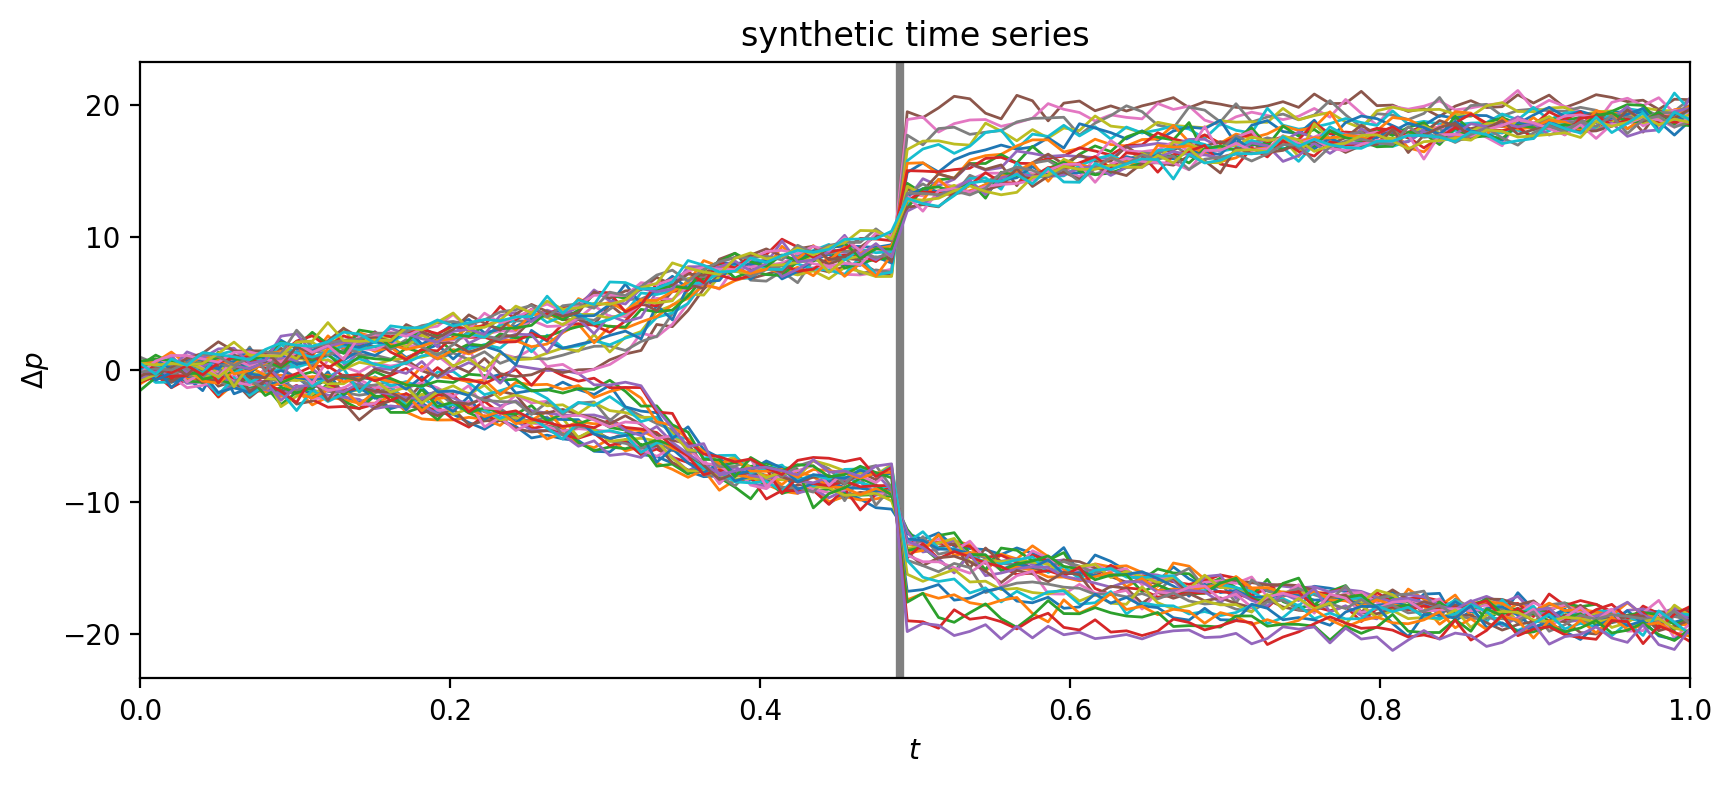

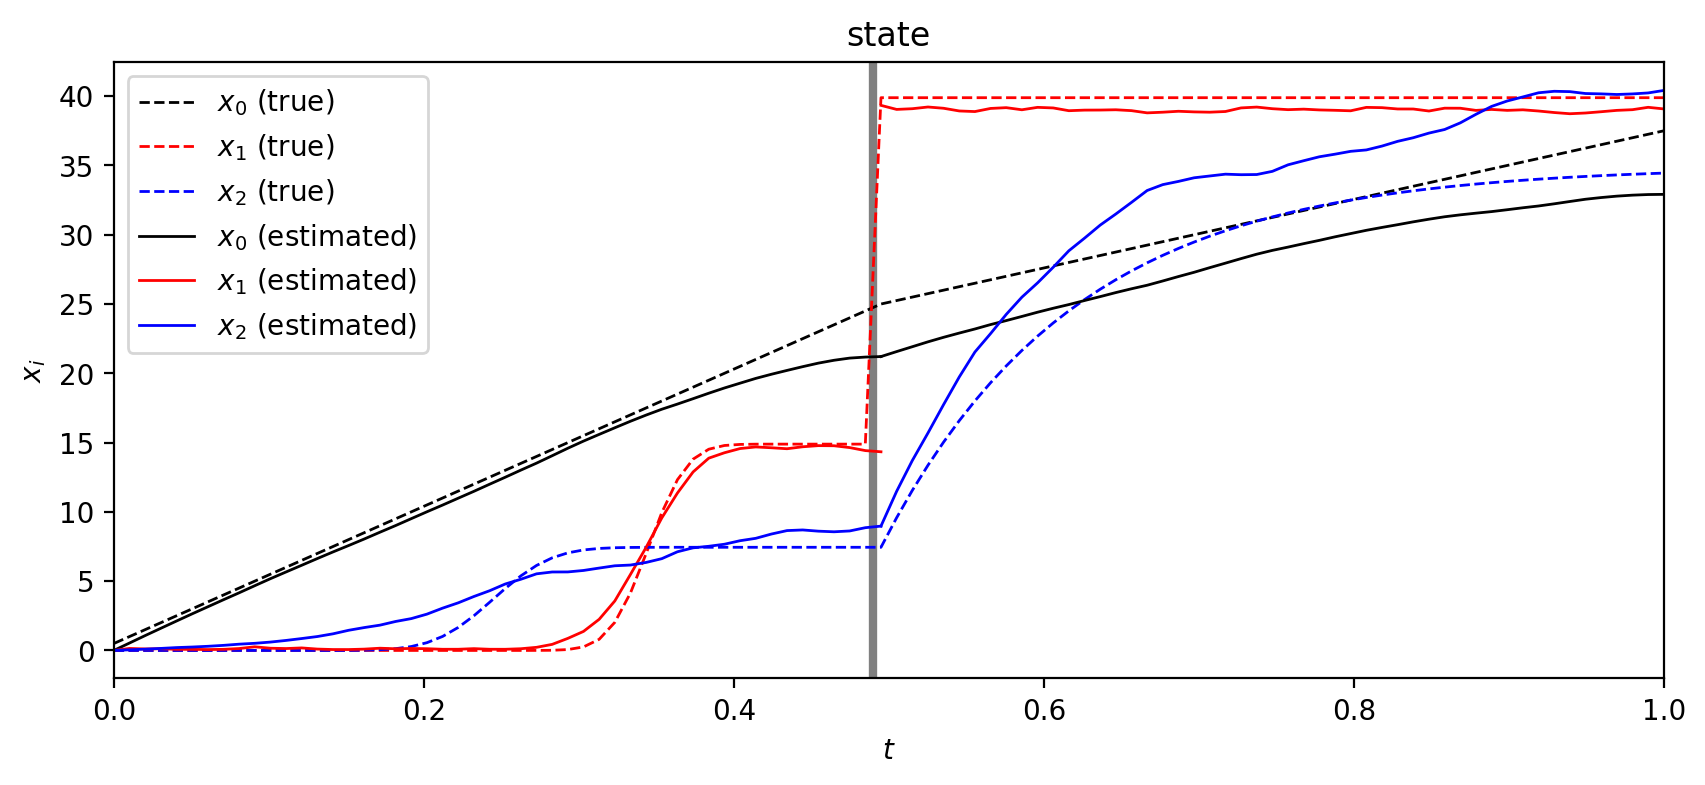

In [5]:
LINEWIDTH = 1.0

# Plot observed time series
plt.figure(figsize=(10, 4))
plt.axvline(x=0.49, color="gray", linestyle="-", linewidth=3)
for i in range(50):
    plt.plot(
        t_vec,
        100 * b_noise[i, :],
        "-",
        linewidth=LINEWIDTH,
    )
plt.xlabel("$t$")
plt.ylabel("$\Delta p$")
plt.xlim([0, 1])
plt.title("synthetic time series")
plt.show()


# Plot true and and estimated state
plt.figure(figsize=(10, 4))
plt.axvline(x=0.49, color="gray", linestyle="-", linewidth=3)

# Plot true state
plt.plot(t_vec, x0, "--k", label="$x_0$ (true)", linewidth=LINEWIDTH)
plt.plot(t_vec, x1, "--r", label="$x_1$ (true)", linewidth=LINEWIDTH)
plt.plot(t_vec, x2, "--b", label="$x_2$ (true)", linewidth=LINEWIDTH)

# Plot first batch
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 0] / dt,
    "-k",
    label="$x_0$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 1] / dt,
    "-r",
    label="$x_1$ (estimated)",
    linewidth=LINEWIDTH,
)
plt.plot(
    t_vec[0 : coseismic_idx + 1],
    x_est[:, 2] / dt,
    "-b",
    label="$x_2$ (estimated)",
    linewidth=LINEWIDTH,
)

# Plot second batch
plt.plot(t_vec[coseismic_idx::], x_est_post[:, 0] / dt, "-k", linewidth=LINEWIDTH)
plt.plot(
    t_vec[coseismic_idx::],
    x_est_post[:, 1] / dt + np.max(np.diff(x1)),
    "-r",
    linewidth=LINEWIDTH,
)
plt.plot(t_vec[coseismic_idx::], x_est_post[:, 2] / dt, "-b", linewidth=LINEWIDTH)

plt.xlabel("$t$")
plt.ylabel("$x_i$")
plt.xlim([0, 1])
plt.legend()
plt.title("state")
plt.show()